In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv('AIML Dataset.csv')
data.shape

(6362620, 11)

EDA

In [4]:
data.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0


In [5]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
data.isFlaggedFraud.value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [8]:
data.isFraud.value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
# check for nulls
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
(data.isFraud.value_counts()[1] / data.shape[0]) * 100

# 0.13% fraud

np.float64(0.12908204481801522)

Text(0, 0.5, 'counts')

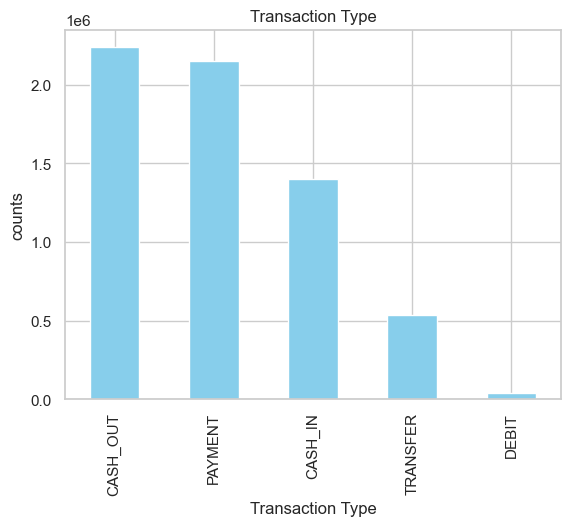

In [11]:
data.type.value_counts().plot(kind="bar", title="Transaction Type", color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("counts")

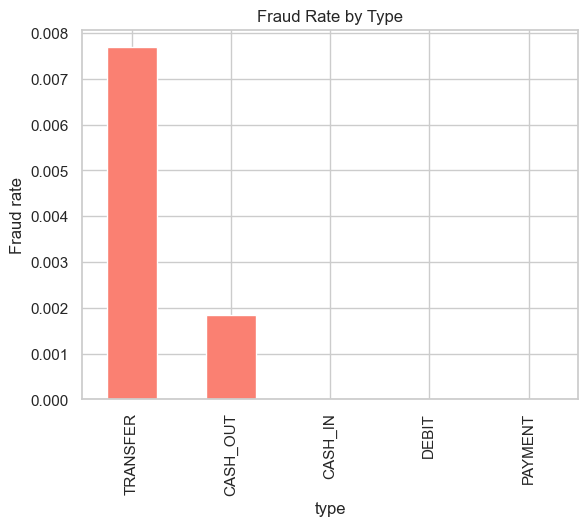

In [12]:
fraud_by_type = data.groupby("type")['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', title='Fraud Rate by Type', color='salmon')
plt.ylabel('Fraud rate')
plt.show()

# transfers have highest fraud rate

In [13]:
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [14]:
data['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

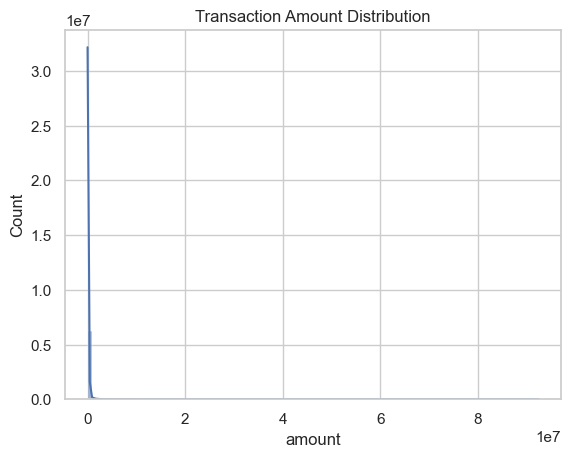

In [15]:
sns.histplot(data.amount, bins=100, kde=True) #kde= kernel desnity estimate to smooth the distribution
plt.title('Transaction Amount Distribution')
plt.xlabel("amount")
plt.show()

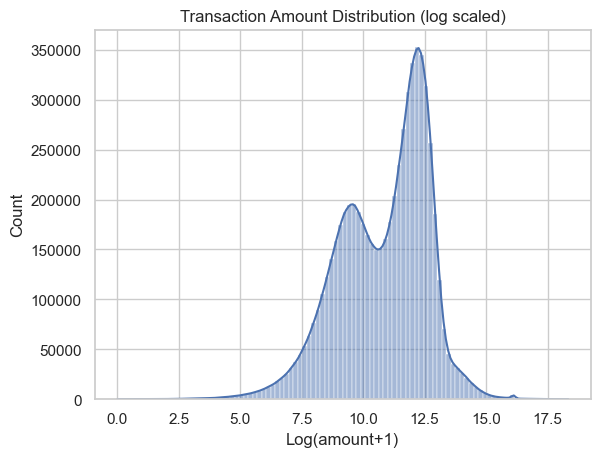

In [16]:
# transaction amounts are skewed --> log scaling

sns.histplot(np.log1p(data.amount), bins=100, kde=True) #kde= kernel desnity estimate to smooth the distribution
plt.title('Transaction Amount Distribution (log scaled)')
plt.xlabel("Log(amount+1)")
plt.show()

#

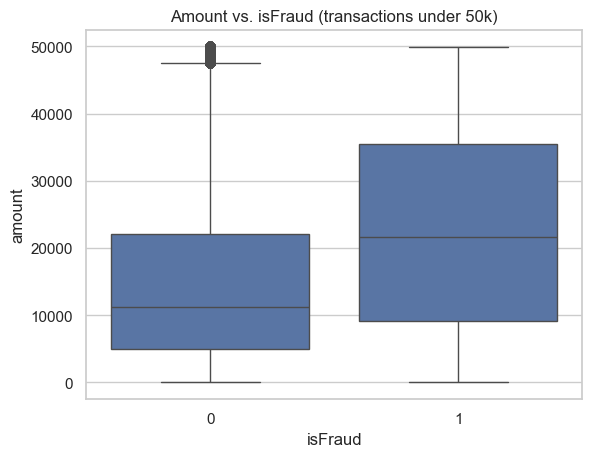

In [17]:
sns.boxplot(data[data.amount<50000], x='isFraud', y='amount')
plt.title('Amount vs. isFraud (transactions under 50k)')
plt.show()

# for higher amounts we have higher fraud rates (mean is over 20,000)
# mean closer to 10,000 on the non-fraudulent transactions

In [18]:
# any negative balances on 
data['balancediffOrig'] = data['oldbalanceOrg'] - data['newbalanceOrig']
data['balancediffDest'] = data['newbalanceDest'] - data['oldbalanceDest']

In [19]:
(data['balancediffOrig']<0).sum()

np.int64(1399253)

In [20]:
(data['balancediffDest']<0).sum()

np.int64(1238864)

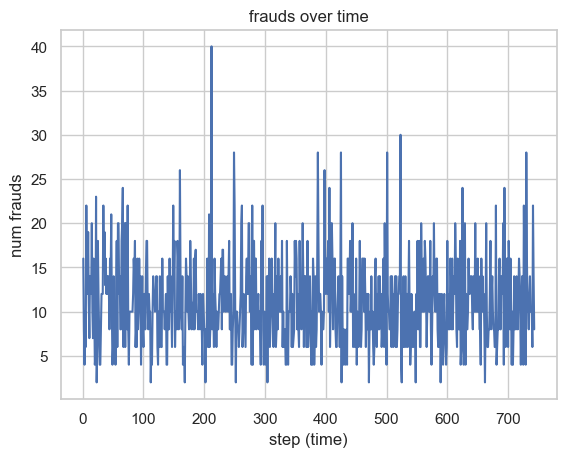

In [21]:
frauds_per_step = data[data.isFraud==1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="frauds per step")
plt.xlabel("step (time)")
plt.ylabel("num frauds")
plt.title("frauds over time")
plt.grid(True)
plt.show()



In [22]:
# fraud does not seem time dependent, so we can drop this column

data = data.drop(columns='step')

In [24]:
# view top fraud senders

top_senders = data['nameOrig'].value_counts().head(10)
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [25]:
# view top fraud receivers

top_receivers = data['nameDest'].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [27]:
# top 10 fraud users - transaction counts

fraud_users = data[data.isFraud==1].nameOrig.value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [28]:
fraud_types = data[data.type.isin(["TRANSFER", "CASH_OUT"])]
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediffOrig,balancediffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [29]:
fraud_types.type.value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

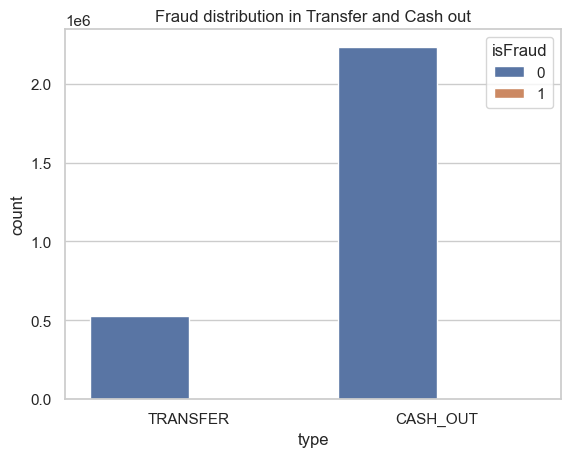

In [30]:
sns.countplot(data=fraud_types, x="type", hue='isFraud')
plt.title("Fraud distribution in Transfer and Cash out")
plt.show()

# distribution of fraudulent transcations by transaction type

In [33]:
# correlation matrix - check correlations between features

corr = data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest','isFraud']].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


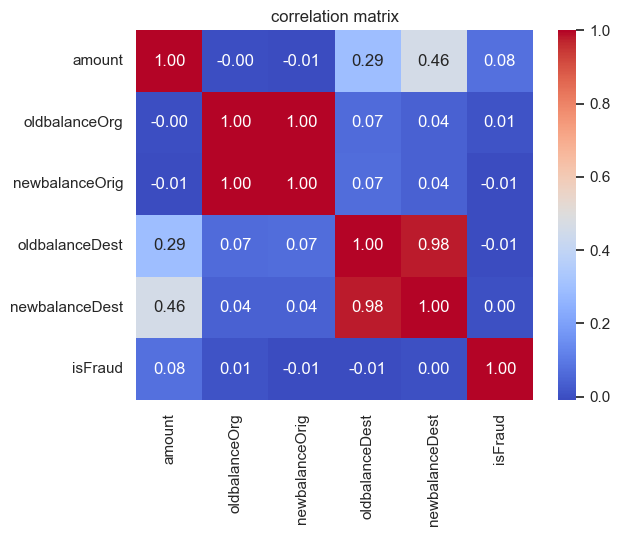

In [34]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("correlation matrix")
plt.show()

# -1 = strong negative correlation
# +1 = strong positive correlation
# 0 = no correlation

# high correlation between new balance dest and old balance dest (0.98 and 1.00)
# slight correlation (0.29) between old balance dest and amount
# slight correlation (0.46) between new balance dest and amount


In [37]:
# suspicious records - zero after transaction

zero_after_trans = data[(data.oldbalanceOrg>0)&(data.newbalanceOrig==0)&(data.type.isin(["TRANSFER", "CASH_OUT"]))]
print(len(zero_after_trans))
zero_after_trans.head()

1188074


,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediffOrig,balancediffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


Feature Engineering & Model Building

In [39]:
data.isFraud.value_counts()

# class imbalance

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [41]:
data_model = data.drop(columns=['nameOrig','nameDest', 'isFlaggedFraud'], axis=1)
data_model.head(1)

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balancediffOrig,balancediffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0


In [56]:
categ_feats = ['type']
num_feats = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

In [43]:
y = data_model['isFraud']
X = data_model.drop('isFraud', axis=1)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [57]:
# preprocessing

preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), num_feats),
        ("cat", OneHotEncoder(drop='first'), categ_feats)
    ],
    remainder='drop'
)

In [58]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [59]:
pipeline.fit(X_train, y_train) # train log reg model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [61]:
# make predictions
y_pred = pipeline.predict(X_test)

In [63]:
print(classification_report(y_test, y_pred))

# precision not great
# we can improve precision with SMOTE or under sampling or try diff models

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.93      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [64]:
confusion_matrix(y_test, y_pred)

array([[1805970,  100352],
       [    166,    2298]])

In [65]:
pipeline.score(X_test, y_test)

0.9473393036202068

In [66]:
import joblib

# export pipeline as pickle
joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']